##Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Import the datasets and attach and Load Data

In [2]:
df = pd.read_csv('11_nyc_taxi_fare.csv')
key = pd.read_csv('_key_11_true_rate_code.csv')

In [3]:
assert len(df) == len(key)
df['true_rate_code'] = key['true_rate_code'].values

In [4]:
print( df.shape)

(5120, 36)



## 01 Data cleaning

### 1.1 Remove duplicate rows

120 rows are byte identical across all original columns *including*
`trip_id` and `medallion_id`. A genuinely repeated trip would carry a distinct
`trip_id`, so these are double-logged export records rather than real trips.
Leaving them in would over-weight those trips during training and, worse, leak
identical rows across the train/test split, inflating test scores.



In [5]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'removed {before - len(df)} duplicate rows -> {len(df)} remain')

removed 120 duplicate rows -> 5000 remain


### 1.2 Repair coordinates

Three distinct defects, each needing different handling. NYC sits at
roughly +40.7 latitude and -74.0 longitude, so latitude must be positive and
longitude negative. Rows violating that have the two fields transposed and are
**swapped back** - the data is correct, only the column assignment is wrong.
Rows with a coordinate of exactly zero come from a GPS unit that never acquired
a fix, there is no recoverable value, so they become **NaN** and are imputed
later. Setting them to NaN rather than leaving them at zero is essential,
because a haversine distance from (0, 0) points to the Atlantic Ocean and would
poison every derived feature. Ordinary GPS jitter in the remaining rows is real
measurement noise and is left alone.



In [6]:
COORDS = ['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']

swapped = 0
for la, lo in [('pickup_latitude','pickup_longitude'), ('dropoff_latitude','dropoff_longitude')]:
    m = (df[la] < 0) & (df[lo] > 0)
    swapped += m.sum()
    df.loc[m, [la, lo]] = df.loc[m, [lo, la]].values

zeroed = 0
for c in COORDS:
    m = df[c] == 0
    zeroed += m.sum()
    df.loc[m, c] = np.nan

print(f'swapped back : {swapped} coordinate pairs')
print(f'zeros -> NaN : {zeroed} values')
print(f'lat range: {df.pickup_latitude.min():.3f} to {df.pickup_latitude.max():.3f}')
print(f'lon range: {df.pickup_longitude.min():.3f} to {df.pickup_longitude.max():.3f}')

swapped back : 46 coordinate pairs
zeros -> NaN : 264 values
lat range: 40.555 to 40.858
lon range: -74.199 to -73.740


### 1.3 Parse the pickup timestamp

The column mixes `DD/MM/YYYY HH:MM` and `YYYY-MM-DD HH:MM:SS`. Parsing
with default settings either nulls the slash rows or interprets day as month,
silently reversing dates. Each format is parsed **separately with an
explicit format string**, and null counts are compared before and after to prove
no rows were lost.



In [7]:
nulls_before = df['pickup_datetime'].isna().sum()

s = df['pickup_datetime'].astype(str).str.strip()
is_slash = s.str.contains('/')

pickup_dt = pd.Series(pd.NaT, index=df.index, dtype='datetime64[ns]')
pickup_dt[is_slash]  = pd.to_datetime(s[is_slash],  format='%d/%m/%Y %H:%M',    errors='coerce')
pickup_dt[~is_slash] = pd.to_datetime(s[~is_slash], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df['pickup_dt'] = pickup_dt

nulls_after = df['pickup_dt'].isna().sum()
print(f'format A (DD/MM/YYYY) : {is_slash.sum()} rows')
print(f'format B (ISO)        : {(~is_slash).sum()} rows')
print(f'nulls before parsing  : {nulls_before}')
print(f'nulls after  parsing  : {nulls_after}')
assert nulls_after == nulls_before, 'Rows were lost during parsing - investigate'
print('PASS: no rows lost')
print(f'date range: {df.pickup_dt.min()}  ->  {df.pickup_dt.max()}')

format A (DD/MM/YYYY) : 620 rows
format B (ISO)        : 4380 rows
nulls before parsing  : 0
nulls after  parsing  : 0
PASS: no rows lost
date range: 2023-01-01 02:39:00  ->  2023-12-31 21:30:00


### 1.4 Convert trip_duration from text to minutes

The column holds strings like `12m` and `1h 1m`. A regex extracts hours
and minutes and combines them into a single numeric quantity.


In [8]:
import re

def parse_duration(x):
    if pd.isna(x):
        return np.nan
    h = re.search(r'(\d+)\s*h', str(x))
    m = re.search(r'(\d+)\s*m', str(x))
    total = (int(h.group(1)) * 60 if h else 0) + (int(m.group(1)) if m else 0)
    return total if total > 0 else np.nan

df['duration_min'] = df['trip_duration'].map(parse_duration)
print(df[['trip_duration','duration_min']].dropna().head(6).to_string(index=False))
print(f'\nnulls: {df.duration_min.isna().sum()}   median: {df.duration_min.median():.1f} min')

trip_duration  duration_min
          12m          12.0
          27m          27.0
          34m          34.0
           4m           4.0
          12m          12.0
          42m          42.0

nulls: 58   median: 27.0 min


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   trip_id                  5000 non-null   object        
 1   medallion_id             5000 non-null   object        
 2   driver_name              5000 non-null   object        
 3   driver_experience_years  5000 non-null   float64       
 4   vendor_name              5000 non-null   object        
 5   vehicle_type             5000 non-null   object        
 6   pickup_datetime          5000 non-null   object        
 7   dropoff_datetime         5000 non-null   object        
 8   trip_duration            4942 non-null   object        
 9   pickup_latitude          4926 non-null   float64       
 10  pickup_longitude         4926 non-null   float64       
 11  dropoff_latitude         4942 non-null   float64       
 12  dropoff_longitude        4942 non-

### 1.5 Convert total_amount from text to numeric

It is stored with a currency symbol and thousands separators, so pandas
reads it as text. It is needed as a *numeric* value to detect the 10x target
corruption. It is **not** used as a feature - it algebraically contains
the target.

In [10]:
df['total_amount'] = pd.to_numeric(
    df['total_amount'].astype(str).str.replace(r'[$,]', '', regex=True), errors='coerce')
print(df['total_amount'].describe().round(2).to_string())

count    5000.00
mean       58.41
std        40.09
min         6.49
25%        31.77
50%        46.76
75%        74.84
max       458.26


###1.6 Normalise the dirty categorical columns

`vendor_name`, `payment_type` and `weather_condition` each write the
same real category several ways - different case, trailing whitespace, and
abbreviations alongside full names. One-hot encoding before normalising would
create phantom levels (`VTS` and `vts ` as separate columns), splitting the
signal across duplicate features and inflating dimensionality for nothing.



In [11]:
for col in ['vendor_name','payment_type','weather_condition']:
    print(f'{col}: {df[col].nunique(dropna=False)} raw ->')

df['vendor_name'] = df['vendor_name'].str.strip().str.upper()
df['weather_condition'] = df['weather_condition'].str.strip().str.title()
df['payment_type'] = (df['payment_type'].str.strip().str.upper()
                        .replace({'CRD':'CREDIT CARD', 'CSH':'CASH'}))

vendor_name: 6 raw ->
payment_type: 7 raw ->
weather_condition: 7 raw ->


In [12]:
print()
for col in ['vendor_name','payment_type','weather_condition']:
    print(f'{col:20s} -> {sorted(df[col].dropna().unique())}')


vendor_name          -> ['CMT', 'VERIFONE', 'VTS']
payment_type         -> ['CASH', 'CREDIT CARD', 'DISPUTE', 'NO CHARGE']
weather_condition    -> ['Clear', 'Fog', 'Rain', 'Snow']


### 1.7 Sentinels and impossible values

`temperature_f` uses **-999** for a missing reading. Left in place it drags
the column mean far below any real temperature and destroys every correlation
involving weather.

`passenger_count` contains **0** (impossible - a trip occurred) and **9**
(above the 6-passenger legal maximum for a NYC taxi). Both are set to NaN
rather than clipped, because the true value is genuinely unknown and clipping
would invent a specific wrong number. They are imputed later, inside the
preprocessing section, fitted on the training split only.

In [13]:
print(f'temperature_f == -999 : {(df.temperature_f <= -100).sum()} rows')
df.loc[df['temperature_f'] <= -100, 'temperature_f'] = np.nan

bad_pax = (df.passenger_count < 1) | (df.passenger_count > 6)
print(f'passenger_count out of range : {bad_pax.sum()} rows')
df.loc[bad_pax, 'passenger_count'] = np.nan

print(f'\ntemperature_f now: {df.temperature_f.min():.1f} to {df.temperature_f.max():.1f} F')
print(f'passenger_count now: {sorted(df.passenger_count.dropna().unique())}')

temperature_f == -999 : 37 rows
passenger_count out of range : 84 rows

temperature_f now: 1.0 to 105.0 F
passenger_count now: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]


### 1.8 Repair the target

**Nulls (10 rows) - DROP.** A row with no label can neither train nor test a
model. Imputing a target is not imputation, it is fabrication.

**Negative fares (13 rows) - DROP.** A metered fare cannot be negative. These are
refunds or meter faults with no recoverable true value.

**Zero fares (9 rows) - DROP.** No fare was charged. These are voided or
cancelled trips, not genuine \$0 rides, and training on them teaches the model
that some real trips are free.

**Inflated 10x (14 rows) - REPAIR, do not drop.** `total_amount` was not
inflated, and `total` must always be at least `fare` since it is fare plus tip,
tolls and surcharges. Any row where `fare > total` is therefore a decimal-point
error. Dividing by 10 leaves a residual exactly equal to the fixed surcharges,
which confirms the diagnosis. The trip is real - only the decimal moved - so it
is repaired and kept.



In [14]:
print(f'  nulls    : {df.fare_amount.isna().sum()}')
print(f'  negative : {(df.fare_amount < 0).sum()}')
print(f'  zero     : {(df.fare_amount == 0).sum()}')

inflated = df['fare_amount'] > df['total_amount']
print(f'  10x error: {inflated.sum()}')
display(df.loc[inflated, ['fare_amount','total_amount','tip_amount','tolls_amount']]
          .assign(**{'fare/10': lambda x: x.fare_amount/10}).round(2).head(6))

df.loc[inflated, 'fare_amount'] = df.loc[inflated, 'fare_amount'] / 10

n0 = len(df)
df = df[df['fare_amount'].notna() & (df['fare_amount'] > 0)].reset_index(drop=True)

print(f'AFTER repaired {inflated.sum()}, dropped {n0-len(df)} -> {len(df)} rows remain')
print(df.fare_amount.describe().round(2).to_string())

  nulls    : 10
  negative : 13
  zero     : 9
  10x error: 14


,fare_amount,total_amount,tip_amount,tolls_amount,fare/10
863,793.6,118.87,15.96,17.75,79.36
1175,396.7,52.77,0.00,7.30,39.67
1458,298.8,35.68,0.00,0.00,29.88
2241,834.0,103.22,16.52,0.00,83.40
2391,250.2,37.64,7.24,4.58,25.02
2739,538.6,66.68,8.52,0.00,53.86


AFTER repaired 14, dropped 32 -> 4968 rows remain
count    4968.00
mean       46.57
std        32.30
min         4.05
25%        24.85
50%        37.63
75%        63.42
max       337.22


### 1.9 The structural missingness in `congestion_surcharge`

Why this is not a normal imputation. The missing values form a **contiguous
block of early months**, not a random scatter. The congestion surcharge did not
exist for those trips - the charge was introduced partway through the period.
Filling with the median would invent $2.50 of history that was never charged,
and would corrupt any reconciliation against `total_amount`. The correct fill is
**0.0**, the amount actually charged. Having done that, the column is still
effectively constant among charged trips, so it is dropped as a feature - but
the cutoff date is recorded because it explains a genuine regime change in the
data.



In [15]:
gap = df.groupby(df.pickup_dt.dt.to_period('M'))['congestion_surcharge'].apply(lambda x: x.isna().mean()*100)
print(gap.round(1).to_string())

first_charged = df.loc[df.congestion_surcharge.notna(), 'pickup_dt'].min()
print(f'\nFirst trip carrying the surcharge: {first_charged}')

df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0.0)

pickup_dt
2023-01    100.0
2023-02    100.0
2023-03    100.0
2023-04      0.0
2023-05      0.0
2023-06      0.0
2023-07      0.0
2023-08      0.0
2023-09      0.0
2023-10      0.0
2023-11      0.0
2023-12      0.0
Freq: M

First trip carrying the surcharge: 2023-04-01 03:50:00


##02 Feature engineering



### 2.1 Haversine distance from the coordinates

The recorded `trip_distance` is a post-trip meter reading. The
great-circle distance between the two points the customer entered is available
at quote time, which makes it the correct distance feature for this model.

In [16]:
def haversine_miles(lat1, lon1, lat2, lon2):

    R = 3958.8
    p = np.pi / 180
    a = (np.sin((lat2-lat1)*p/2)**2
         + np.cos(lat1*p) * np.cos(lat2*p) * np.sin((lon2-lon1)*p/2)**2)
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df['hav_miles'] = haversine_miles(df.pickup_latitude, df.pickup_longitude,
                                  df.dropoff_latitude, df.dropoff_longitude)
print(df.hav_miles.describe().round(3).to_string())

count    4837.000
mean        7.336
std         4.376
min         0.124
25%         3.860
50%         6.235
75%        10.585
max        22.747


### 2.2 Repair the distance unit corruption

Dividing the recorded distance by the haversine distance gives the road
circuity factor, which for a real city grid sits around 1.15-1.55. The observed
ratio is sharply bimodal with an empty gap between 1.55 and 1.85, and the
upper mode is the lower mode multiplied by 1.609 - the miles to kilometres
factor. Rows above the gap were logged in km and are converted, not deleted
they are a meaningful fraction of the data.



In [17]:
ratio = (df['trip_distance'] / df['hav_miles']).replace([np.inf, -np.inf], np.nan)

MI_PER_KM = 1 / 1.609344
df['logged_in_km'] = (ratio > 1.7).astype(int)
df['trip_distance_mi'] = np.where(df.logged_in_km == 1,
                                  df.trip_distance * MI_PER_KM, df.trip_distance)
df.loc[df.trip_distance <= 0, 'trip_distance_mi'] = np.nan

print(f'converted {df.logged_in_km.sum()} rows from km to miles')
new_ratio = (df.trip_distance_mi / df.hav_miles).replace([np.inf,-np.inf], np.nan)
print(f'ratio after repair median {new_ratio.median():.3f}, '
      f'p5 {new_ratio.quantile(.05):.3f}, p95 {new_ratio.quantile(.95):.3f}  '
      )

converted 1248 rows from km to miles
ratio after repair median 1.363, p5 1.199, p95 1.530  


In [18]:
df.head()

,trip_id,medallion_id,driver_name,driver_experience_years,vendor_name,vehicle_type,pickup_datetime,dropoff_datetime,trip_duration,pickup_latitude,...,tip_amount,total_amount,trip_rating,fare_amount,true_rate_code,pickup_dt,duration_min,hav_miles,logged_in_km,trip_distance_mi
0,NYC-2023-403274,5492-G29,Driver 1496,9.4,VERIFONE,Sedan,19/07/2023 19:36,2023-07-19 19:48:00,12m,40.702822,...,3.02,25.37,5.0,16.55,1,2023-07-19 19:36:00,12.0,1.974616,0,2.510000
1,NYC-2023-402541,5048-G18,Driver 1414,14.8,VTS,Sedan,2023-10-31 06:21:00,2023-10-31 06:55:00,34m,40.693452,...,11.77,57.02,4.0,41.95,1,2023-10-31 06:21:00,34.0,6.343641,0,8.960000
2,NYC-2023-404313,6469-D90,Driver 961,1.2,VTS,Sedan,2023-04-04 05:08:00,2023-04-04 05:12:00,4m,40.792349,...,2.96,17.92,5.0,10.66,1,2023-04-04 05:08:00,4.0,1.459521,0,1.810000
3,NYC-2023-404984,5788-E18,Driver 236,2.7,VERIFONE,Hybrid,2023-11-17 04:17:00,2023-11-17 04:29:00,12m,40.795941,...,2.92,28.91,4.0,21.69,1,2023-11-17 04:17:00,12.0,3.321140,1,4.623002
4,NYC-2023-404291,7217-C16,Driver 1495,4.8,VTS,SUV,2023-04-16 03:32:00,2023-04-16 04:14:00,42m,40.711229,...,10.31,105.25,5.0,74.48,3,2023-04-16 03:32:00,42.0,14.117198,0,20.100000


## 2.3 Average speed

With a corrected distance in miles and a duration in minutes, the
natural derived quantity is speed. It is not distance divided by duration in
raw form that gives miles per minute. Multiplying by 60 gives miles per hour,
which is interpretable and comparable to real traffic speeds, and which acts as
a strong validation that the unit repair in 2.2 was correct.

This feature is diagnostic only and is excluded from the model, because it
depends on actual trip duration.



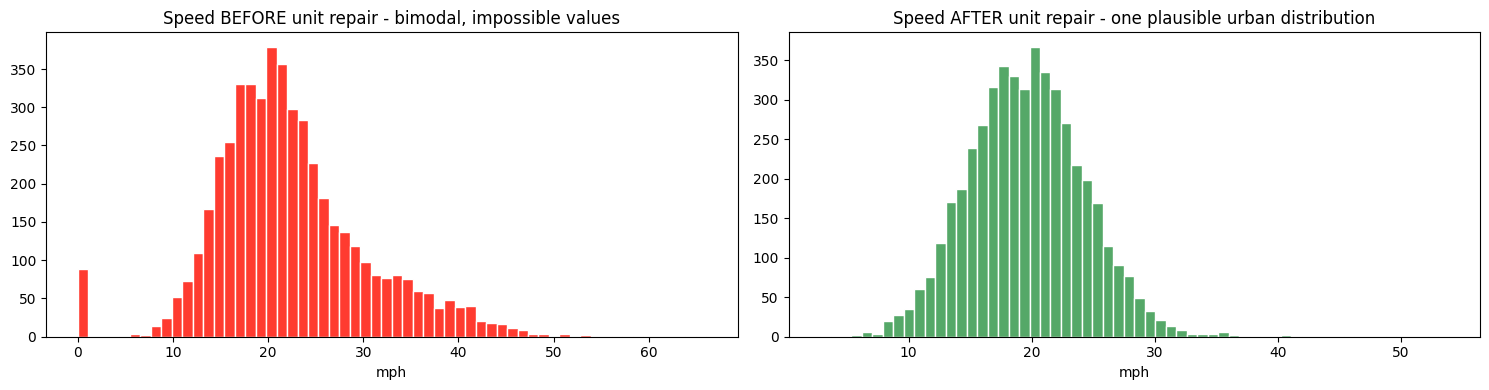

count    4823.00
mean       19.62
std         4.74
min         2.80
25%        16.40
50%        19.56
75%        22.64
max        53.89


In [19]:
df['avg_speed_mph'] = df['trip_distance_mi'] / (df['duration_min'] / 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
raw_speed = df['trip_distance'] / (df['duration_min'] / 60)
axes[0].hist(raw_speed.dropna().clip(0, 80), bins=60, color='#FF3B30', edgecolor='white')
axes[0].set_title('Speed BEFORE unit repair - bimodal, impossible values')
axes[1].hist(df.avg_speed_mph.dropna().clip(0, 80), bins=60, color='#55A868', edgecolor='white')
axes[1].set_title('Speed AFTER unit repair - one plausible urban distribution')
for a in axes: a.set_xlabel('mph')
plt.tight_layout(); plt.show()

print(df.avg_speed_mph.describe().round(2).to_string())

### 2.4 Datetime components

Fare depends heavily on when a trip happened rush-hour congestion
raises metered time charges, night trips run faster, and demand is seasonal.
Hour and month are cyclical - hour 23 is adjacent to hour 0 - so they are
additionally encoded as sine/cosine pairs so that linear models can see the
wrap-around. The raw integer versions are kept as well because tree models split
on them more naturally.



In [20]:
d = df['pickup_dt']
df['year']       = d.dt.year
df['month']      = d.dt.month
df['day']        = d.dt.day
df['hour']       = d.dt.hour
df['dayofweek']  = d.dt.dayofweek
df['weekofyear'] = d.dt.isocalendar().week.astype(int)

df['is_weekend'] = (df.dayofweek >= 5).astype(int)
df['is_rush']    = df.hour.isin([7,8,9,16,17,18,19]).astype(int)
df['is_night']   = ((df.hour >= 22) | (df.hour <= 5)).astype(int)

df['hour_sin']  = np.sin(2*np.pi*df.hour/24);   df['hour_cos']  = np.cos(2*np.pi*df.hour/24)
df['month_sin'] = np.sin(2*np.pi*df.month/12);  df['month_cos'] = np.cos(2*np.pi*df.month/12)

print(df[['hour','dayofweek','is_weekend','is_rush','is_night','hour_sin','hour_cos']].head(10))

   hour  dayofweek  is_weekend  is_rush  is_night  hour_sin      hour_cos
0    19          2           0        1         0 -0.965926  2.588190e-01
1     6          1           0        0         0  1.000000  6.123234e-17
2     5          1           0        0         1  0.965926  2.588190e-01
3     4          4           0        0         1  0.866025  5.000000e-01
4     3          6           1        0         1  0.707107  7.071068e-01
5    15          6           1        0         0 -0.707107 -7.071068e-01
6     2          1           0        0         1  0.500000  8.660254e-01
7     0          6           1        0         1  0.000000  1.000000e+00
8    23          2           0        0         1 -0.258819  9.659258e-01
9    23          4           0        0         1 -0.258819  9.659258e-01


### 2.5 THE PRICING REGIME FLAG

This is the highest-value feature in the project. the supplied column cannot be used. `rate_code` is null for 38% of rows
and, where populated, disagrees with ground truth on about 1% of rows. A feature
that is missing for over a third of the data and wrong for part of the rest is
not usable.

How the flag is rebuilt. NYC taxi pricing is determined by where the trip
starts and ends, and both endpoints are known at quote time. The rules

| Regime | Rule | Detection |
|---|---|---|
| 2 - JFK flat fare | JFK airport to/from Manhattan | within 2.0 mi of (40.6413, -73.7781) **and** other end in Manhattan |
| 3 - Newark | trip touching Newark / EWR | within 3.0 mi of (40.6895, -74.1745) |
| 4 - Out-of-city flat | trip touching Staten Island | Staten Island endpoint |
| 1 - Standard metered | everything else | default |
| 5 - Negotiated | individually agreed | not geographically detectable - see below|

The Manhattan condition matters. JFK trips to Brooklyn or Queens are metered
at the standard rate, not flat-rated. Flagging on airport proximity alone
misclassifies over 300 standard trips. Requiring a Manhattan endpoint removes
every one of those false positives.

Precedence runs 4 → 3 → 2 → 1, because a Staten Island or Newark endpoint
overrides everything else.



In [21]:
JFK = (40.6413, -73.7781)
LGA = (40.7769, -73.8740)
EWR = (40.6895, -74.1745)

p_jfk = haversine_miles(df.pickup_latitude,  df.pickup_longitude,  *JFK)
d_jfk = haversine_miles(df.dropoff_latitude, df.dropoff_longitude, *JFK)
p_ewr = haversine_miles(df.pickup_latitude,  df.pickup_longitude,  *EWR)
d_ewr = haversine_miles(df.dropoff_latitude, df.dropoff_longitude, *EWR)
p_lga = haversine_miles(df.pickup_latitude,  df.pickup_longitude,  *LGA)
d_lga = haversine_miles(df.dropoff_latitude, df.dropoff_longitude, *LGA)

df['dist_to_JFK'] = np.minimum(p_jfk, d_jfk)
df['dist_to_EWR'] = np.minimum(p_ewr, d_ewr)
df['dist_to_LGA'] = np.minimum(p_lga, d_lga)

regime = pd.Series(1, index=df.index, name='rate_regime')
regime[((p_jfk < 2.0) & (df.dropoff_borough == 'Manhattan')) |
       ((d_jfk < 2.0) & (df.pickup_borough  == 'Manhattan'))] = 2
regime[(p_ewr < 3.0) | (d_ewr < 3.0)] = 3
regime[(df.pickup_borough == 'Staten Island') | (df.dropoff_borough == 'Staten Island')] = 4
df['rate_regime'] = regime

print(df.rate_regime.value_counts().sort_index().to_string())

rate_regime
1    3929
2     509
3     355
4     175


### 2.6 Score the engineered flag against the answer key

The key is used here, for validation only. It never enters the feature set.



Overall accuracy vs the key           : 97.08%
Accuracy excluding regime 5           : 99.65%


ENGINEERED,1,2,3,4
TRUE,,,,
1,3786,0,0,0
2,12,509,0,0
3,3,0,355,2
4,0,0,0,173
5,128,0,0,0


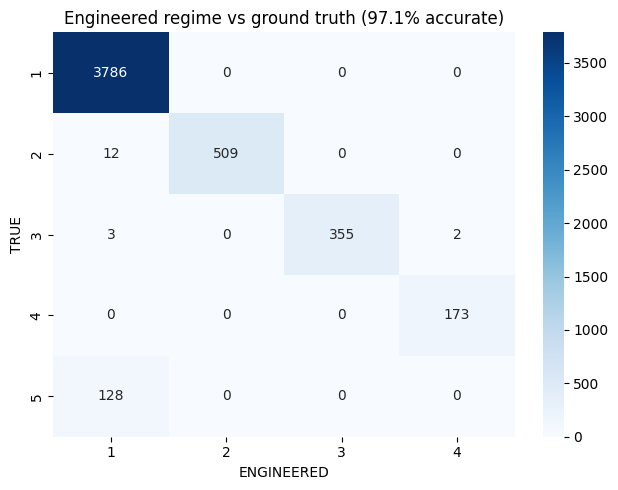

In [22]:
acc = (df.rate_regime == df.true_rate_code).mean()
mask = df.true_rate_code != 5
acc_ex5 = (df.rate_regime[mask] == df.true_rate_code[mask]).mean()

print(f'Overall accuracy vs the key           : {acc:.2%}')
print(f'Accuracy excluding regime 5           : {acc_ex5:.2%}')

cm = pd.crosstab(df.true_rate_code, df.rate_regime,
                 rownames=['TRUE'], colnames=['ENGINEERED'])
display(cm)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Engineered regime vs ground truth ({acc:.1%} accurate)')
plt.tight_layout(); plt.show()

### 2.7 Remaining geographic features

A tree model can partially reconstruct geography by splitting on raw
coordinates, but a linear model cannot. Explicit airport distances, a
cross-borough flag and the coordinate deltas give the linear models access to the
same structure - which is why they improve far more from these features than the
trees do.



In [23]:
df['is_airport']     = ((df.dist_to_JFK < 2) | (df.dist_to_LGA < 2) | (df.dist_to_EWR < 3)).astype(int)
df['cross_borough']  = (df.pickup_borough != df.dropoff_borough).astype(int)
df['abs_dlat']       = (df.dropoff_latitude  - df.pickup_latitude ).abs()
df['abs_dlon']       = (df.dropoff_longitude - df.pickup_longitude).abs()
df['manhattan_dist'] = (haversine_miles(df.pickup_latitude, df.pickup_longitude, df.dropoff_latitude, df.pickup_longitude)
                      + haversine_miles(df.dropoff_latitude, df.pickup_longitude, df.dropoff_latitude, df.dropoff_longitude))

print(df[['is_airport','cross_borough','abs_dlat','abs_dlon','manhattan_dist']].describe().round(4).to_string())


       is_airport  cross_borough   abs_dlat   abs_dlon  manhattan_dist
count   4968.0000       4968.000  4837.0000  4837.0000       4837.0000
mean       0.3573          0.720     0.0652     0.0972          9.5923
std        0.4792          0.449     0.0452     0.0788          5.9812
min        0.0000          0.000     0.0000     0.0001          0.1686
25%        0.0000          0.000     0.0304     0.0323          4.7967
50%        0.0000          1.000     0.0587     0.0712          7.9354
75%        1.0000          1.000     0.0896     0.1599         13.8354
max        1.0000          1.000     0.2648     0.4231         31.1801


## 03 The leakage audit

#### Before training, every column needs to be checked: would this value actually be known at the moment a customer asks for a fare estimate - BEFORE the ride happens? If a column is only recorded during or after the trip, it has to be dropped, no matter how strongly it correlates with fare_amount. Keeping it would let the model "cheat" during training by seeing information it will never have access to when making a real prediction later. Each column below is dropped one at a time, with the reason for that specific column - same idea as dropping Date_of_Journey after extracting Date/Month/Year in the feature engineering step earlier.

In [24]:
# dropoff_datetime - the trip hasn't happened yet at the moment of the quote

df.drop('dropoff_datetime', axis=1, inplace=True)

In [25]:
# trip_duration - actual elapsed time, only known once the trip ends

df.drop('trip_duration', axis=1, inplace=True)

In [26]:
# trip_distance - actual metered distance, recorded during the ride

df.drop('trip_distance', axis=1, inplace=True)

In [27]:
# tolls_amount - actual tolls incurred during the ride, not known in advance

df.drop('tolls_amount', axis=1, inplace=True)

In [28]:
# tip_amount - chosen by the passenger at payment, after the ride is over

df.drop('tip_amount', axis=1, inplace=True)

In [29]:
# store_and_fwd_flag - a meter status flag written DURING the trip

df.drop('store_and_fwd_flag', axis=1, inplace=True)

In [30]:
# payment_type - selected by the passenger at the end of the trip

df.drop('payment_type', axis=1, inplace=True)

In [31]:
# total_amount - this is the most dangerous one. It is fare_amount PLUS tip,
# tolls, and surcharges added together, so it algebraically contains the
# target. Including it would make the model look almost perfect during
# training while being useless in production, because nobody knows the
# total before the ride happens.

df.drop('total_amount', axis=1, inplace=True)

In [32]:
# driver_name, driver_experience_years - no driver is assigned to a trip
# until after the customer books, so neither is known at quote time

df.drop(['driver_name', 'driver_experience_years'], axis=1, inplace=True)

In [33]:
# vendor_name, vehicle_type - no vehicle is assigned yet either.

df.drop(['vendor_name', 'vehicle_type'], axis=1, inplace=True)

In [34]:
# rate_code - 38% missing, and wrong on part of what remains.
# Already replaced by rate_regime, engineered from geography earlier.

df.drop('rate_code', axis=1, inplace=True)

In [35]:
# true_rate_code - this is the answer key. It was used earlier ONLY to
# check the accuracy of the rate_regime feature we engineered - it must
# never be given to the model as an input, or the model would just be
# looking up the answer instead of learning to predict it.

groups = df['true_rate_code'].copy()
df.drop('true_rate_code', axis=1, inplace=True)

In [36]:
# trip_rating - given by the passenger after dropoff, not known at quote time

df.drop('trip_rating', axis=1, inplace=True)

In [37]:
# trip_distance_mi - the actual metered distance after unit repair.
# Still a post-trip value, replaced by hav_miles from the coordinates.

df.drop('trip_distance_mi', axis=1, inplace=True)

In [38]:
# duration_min - actual elapsed time in minutes, only known once the trip ends

df.drop('duration_min', axis=1, inplace=True)

In [39]:
# avg_speed_mph - derived from actual duration, so also post-trip.
# It was built only to validate that the unit repair worked.

df.drop('avg_speed_mph', axis=1, inplace=True)

In [40]:
# logged_in_km - a cleaning artefact describing which logging system wrote
# the row, not a property of the trip itself

df.drop('logged_in_km', axis=1, inplace=True)

In [41]:
# trip_id - unique identifier, one distinct value per row, carries no signal

df.drop('trip_id', axis=1, inplace=True)

In [42]:
# medallion_id - unique identifier, same reason as trip_id

df.drop('medallion_id', axis=1, inplace=True)

In [43]:
# mta_tax - zero variance, the same value appears in every single row

df.drop('mta_tax', axis=1, inplace=True)

In [44]:
# improvement_surcharge - zero variance, same value in every row

df.drop('improvement_surcharge', axis=1, inplace=True)

In [45]:
# congestion_surcharge - after filling the structural gap with 0.0 it is
# effectively constant among charged trips, so it adds nothing as a feature

df.drop('congestion_surcharge', axis=1, inplace=True)

In [46]:
# extra_surcharge - fully determined by hour of day, which is already
# captured by is_rush and is_night, so this is redundant

df.drop('extra_surcharge', axis=1, inplace=True)

In [47]:
# year - zero variance, every trip in this dataset is from 2023

df.drop('year', axis=1, inplace=True)

In [48]:
# pickup_datetime - the raw text column with two mixed formats.
# Already parsed into pickup_dt and split into hour/day/month/dayofweek,
# so the original text is no longer needed.

df.drop('pickup_datetime', axis=1, inplace=True)

In [49]:
# pickup_dt - the parsed datetime column. Models cannot use a datetime
# directly; it was only needed to extract the components above.

df.drop('pickup_dt', axis=1, inplace=True)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4968 entries, 0 to 4967
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pickup_latitude    4894 non-null   float64
 1   pickup_longitude   4894 non-null   float64
 2   dropoff_latitude   4910 non-null   float64
 3   dropoff_longitude  4910 non-null   float64
 4   pickup_borough     4968 non-null   object 
 5   dropoff_borough    4968 non-null   object 
 6   passenger_count    4685 non-null   float64
 7   weather_condition  4849 non-null   object 
 8   temperature_f      4932 non-null   float64
 9   precipitation_in   4837 non-null   float64
 10  wind_speed_mph     4968 non-null   float64
 11  traffic_index      4800 non-null   float64
 12  is_holiday         4968 non-null   int64  
 13  fare_amount        4968 non-null   float64
 14  hav_miles          4837 non-null   float64
 15  month              4968 non-null   int32  
 16  day                4968 


## 4. Train / test split

Splitting into 75% train and 25% test, before any encoding or scaling.
Fitting a scaler or encoder on the full dataset first would let test data
leak into the training statistics and make the test score look better than
it really is.

stratify is used because two pricing categories (Newark and Staten Island)
are small - around 7% and 3.5% of rows. A plain random split could leave
too few of them in the test set to measure their error reliably later.

true_rate_code is split alongside X and y as 'groups'. It is the answer key,
so it must stay out of X - but it is needed later, kept row-aligned with the
test set, to break the error down per pricing category.



In [51]:
from sklearn.model_selection import train_test_split

X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=df['rate_regime']
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("g_test shape :", g_test.shape)

X_train shape: (3726, 35)
X_test shape : (1242, 35)
g_test shape : (1242,)


##05 Preprocessing

###5.1 Fill missing values

#### weather_condition has missing values - fill before encoding, otherwise NaN becomes its own phantom category

In [52]:
from sklearn.impute import SimpleImputer

cols_to_encode = ['pickup_borough', 'dropoff_borough', 'weather_condition', 'rate_regime']

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cols_to_encode] = cat_imputer.fit_transform(X_train[cols_to_encode])
X_test[cols_to_encode]  = cat_imputer.transform(X_test[cols_to_encode])

print("Missing in categorical columns:", X_train[cols_to_encode].isnull().sum().sum())

Missing in categorical columns: 0


###5.2 One-hot encoding the categorical columns
Four columns are categorical text, not numbers: pickup_borough,
dropoff_borough, weather_condition, and rate_regime (the pricing category
engineered earlier from geography).

OneHotEncoder turns each category into its own 0/1 column. This is necessary
because models work with numbers, and labelling categories as 1, 2, 3 would
falsely imply an order or distance between them that doesn't exist.

drop='first' removes one category per column to avoid redundant columns that
are perfectly predictable from the others. handle_unknown='ignore' means an
unseen category at prediction time encodes as all zeros instead of crashing.

.fit() is called on X_train only. X_test calls .transform() only - it reuses
the categories learned from training data and never learns from the test set.

In [53]:
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = ['pickup_borough', 'dropoff_borough', 'weather_condition', 'rate_regime']

encoder_multi = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

encoder_multi.fit(X_train[cols_to_encode])

encoded_train = encoder_multi.transform(X_train[cols_to_encode])
encoded_test  = encoder_multi.transform(X_test[cols_to_encode])

col_names_multi = encoder_multi.get_feature_names_out(cols_to_encode)

encoded_train_df = pd.DataFrame(encoded_train, columns=col_names_multi, index=X_train.index)
encoded_test_df  = pd.DataFrame(encoded_test,  columns=col_names_multi, index=X_test.index)

X_train = pd.concat([X_train, encoded_train_df], axis=1).drop(cols_to_encode, axis=1)
X_test  = pd.concat([X_test,  encoded_test_df],  axis=1).drop(cols_to_encode, axis=1)

print("New X_train shape:", X_train.shape)
X_train.head()

New X_train shape: (3726, 47)


,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,passenger_count,temperature_f,precipitation_in,wind_speed_mph,traffic_index,is_holiday,...,dropoff_borough_Manhattan,dropoff_borough_New Jersey,dropoff_borough_Queens,dropoff_borough_Staten Island,weather_condition_Fog,weather_condition_Rain,weather_condition_Snow,rate_regime_2,rate_regime_3,rate_regime_4
609,40.762069,-73.924414,40.690757,-73.993719,4.0,25.0,0.40,5.4,4.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3555,40.773692,-73.988396,40.687776,-73.999273,2.0,57.0,0.00,5.2,2.4,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2794,40.754707,-73.984062,40.678413,-73.997549,1.0,65.0,0.00,7.5,4.8,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2505,40.820054,-73.893088,40.767817,-73.861321,NaN,68.0,0.05,2.7,8.5,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2912,40.826213,-73.947199,40.782221,-73.917669,1.0,74.0,1.14,3.8,4.5,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### 5.3 Fill remaining missing values in the numeric columns

`median` is used rather than `mean` because several of these columns contain
outliers - a few very long trips pull the mean of the distance features
upward, while the median stays representative of a typical trip. The median
is also unaffected by the right-skew visible in the distance distribution.

`.fit_transform()` on `X_train` learns the medians from training data alone.
`.transform()` on `X_test` reuses those same medians - the test set never
contributes to the fill values.

In [54]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train[:] = imputer.fit_transform(X_train)
X_test[:]  = imputer.transform(X_test)

print("Missing in X_train", X_train.isnull().sum().sum())
print("Missing in X_test ", X_test.isnull().sum().sum())

Missing in X_train 0
Missing in X_test  0


### 5.4 Feature scaling

Linear models are sensitive to these differences. A feature with naturally
larger numbers can dominate the fitted coefficients even when it is not
actually more predictive, simply because of its units. Scaling puts every
feature on equal footing so the model weighs them on signal rather than
magnitude. Tree-based models are not scale-sensitive, but scaling does them
no harm, so one scaled matrix is used for all models to keep the comparison
fair.

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Final shape:", X_train_scaled.shape)
X_train_scaled.head()

Final shape: (3726, 47)


,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,passenger_count,temperature_f,precipitation_in,wind_speed_mph,traffic_index,is_holiday,...,dropoff_borough_Manhattan,dropoff_borough_New Jersey,dropoff_borough_Queens,dropoff_borough_Staten Island,weather_condition_Fog,weather_condition_Rain,weather_condition_Snow,rate_regime_2,rate_regime_3,rate_regime_4
0,0.494275,0.356135,-0.754234,-0.495132,1.811206,-1.723380,1.411076,-0.540041,-0.672783,-0.167767,...,-0.875144,-0.209039,-0.628477,-0.166068,4.102164,-0.542816,-0.229221,-0.337986,-0.27727,-0.190891
1,0.726471,-0.443478,-0.806826,-0.556322,0.219003,-0.018616,-0.490759,-0.578505,-1.452939,5.960655,...,1.142669,-0.209039,-0.628477,-0.166068,-0.243774,-0.542816,-0.229221,-0.337986,-0.27727,-0.190891
2,0.347202,-0.389314,-0.972012,-0.537328,-0.577099,0.407575,-0.490759,-0.136164,-0.282705,-0.167767,...,-0.875144,-0.209039,-0.628477,-0.166068,-0.243774,-0.542816,-0.229221,-0.337986,-0.27727,-0.190891
3,1.652659,0.747630,0.605289,0.963524,-0.577099,0.567397,-0.253029,-1.059311,1.521407,-0.167767,...,-0.875144,-0.209039,1.591149,-0.166068,-0.243774,1.842245,-0.229221,-0.337986,-0.27727,-0.190891
4,1.775699,0.071380,0.859410,0.342726,-0.577099,0.887040,4.929472,-0.847756,-0.428984,-0.167767,...,-0.875144,-0.209039,1.591149,-0.166068,-0.243774,1.842245,-0.229221,-0.337986,-0.27727,-0.190891


##06 Model training and comparison

Six regression algorithms are trained on the same scaled training data and
evaluated on the same held out test set, so the comparison is fair.

Three metrics are reported, all in dollars or as a ratio - not accuracy,
because fare_amount is a continuous value, not a category

- **R2** - how much of the variation in fare the model explains
- **MAE** - the average error in dollars per prediction, the most readable metric
- **RMSE** - similar to MAE but penalises large misses more heavily

Train R2 is reported alongside Test R2 to check for overfitting. A model with
a much higher train score than test score has memorised the training rows
rather than learning a general rule.

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Linear Regression'        : LinearRegression(),
    'Decision Tree'            : DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42),
    'Random Forest'            : RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors'      : KNeighborsRegressor(n_neighbors=5),
    'Support Vector Regression': SVR(kernel='rbf', C=100, gamma='scale', epsilon=1.0),
    'Neural Network (ANN)'     : MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=600,
                                              random_state=42, early_stopping=True),
}

results = []
fitted = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    pred_train = model.predict(X_train_scaled)
    pred_test  = model.predict(X_test_scaled)

    fitted[name] = model
    predictions[name] = pred_test

    results.append({
        'Model'   : name,
        'Train R2': r2_score(y_train, pred_train),
        'Test R2' : r2_score(y_test, pred_test),
        'MAE ($)' : mean_absolute_error(y_test, pred_test),
        'RMSE ($)': np.sqrt(mean_squared_error(y_test, pred_test)),
    })
    print(f'{name:28s} done')

comparison = pd.DataFrame(results).sort_values('MAE ($)').reset_index(drop=True)
comparison.round(4)

Linear Regression            done
Decision Tree                done
Random Forest                done
K-Nearest Neighbors          done
Support Vector Regression    done
Neural Network (ANN)         done


,Model,Train R2,Test R2,MAE ($),RMSE ($)
0,Random Forest,0.9870,0.9518,4.5651,7.2313
1,Neural Network (ANN),0.9704,0.9462,5.1586,7.6398
2,Decision Tree,0.9695,0.9348,5.3557,8.4092
3,Support Vector Regression,0.9859,0.9318,5.4149,8.5983
4,Linear Regression,0.9072,0.9267,5.5305,8.9140
5,K-Nearest Neighbors,0.9209,0.9020,7.4655,10.3089


##pick the best model

In [57]:
BEST_NAME = comparison.iloc[0]['Model']
best_model = fitted[BEST_NAME]
best_pred  = predictions[BEST_NAME]

print("BEST MODEL:", BEST_NAME)
print(f"Test R2  : {r2_score(y_test, best_pred):.4f}")
print(f"Test MAE : ${mean_absolute_error(y_test, best_pred):.2f}")

BEST MODEL: Random Forest
Test R2  : 0.9518
Test MAE : $4.57


## Benchmark check

- **R2 above 0.98** would indicate leakage - a post-trip column reaching the
  model. Fare would be almost perfectly predictable only if the model could
  see something recorded after the trip.
- **MAE below $2.50** would indicate the same problem from the other direction.

Passing both means the model is learning from genuine quote-time signal.

In [58]:
r2  = r2_score(y_test, best_pred)
mae = mean_absolute_error(y_test, best_pred)

print(f'Test R2  : {r2:.4f}')
print(f'Test MAE : ${mae:.2f}\n')

if r2 > 0.98:
    print('FAIL - R2 above 0.98 indicates leakage. Audit the feature list.')
elif mae < 2.50:
    print('FAIL - MAE below $2.50 indicates a post-trip column in the features.')
elif mae > 7.00:
    print('WARN - MAE above $7. Check distance units and timestamp parsing.')
else:
    print('PASS - inside the safe band no leakage signature, no unit or parsing fault.')

Test R2  : 0.9518
Test MAE : $4.57

PASS - inside the safe band no leakage signature, no unit or parsing fault.


## Model comparison chart

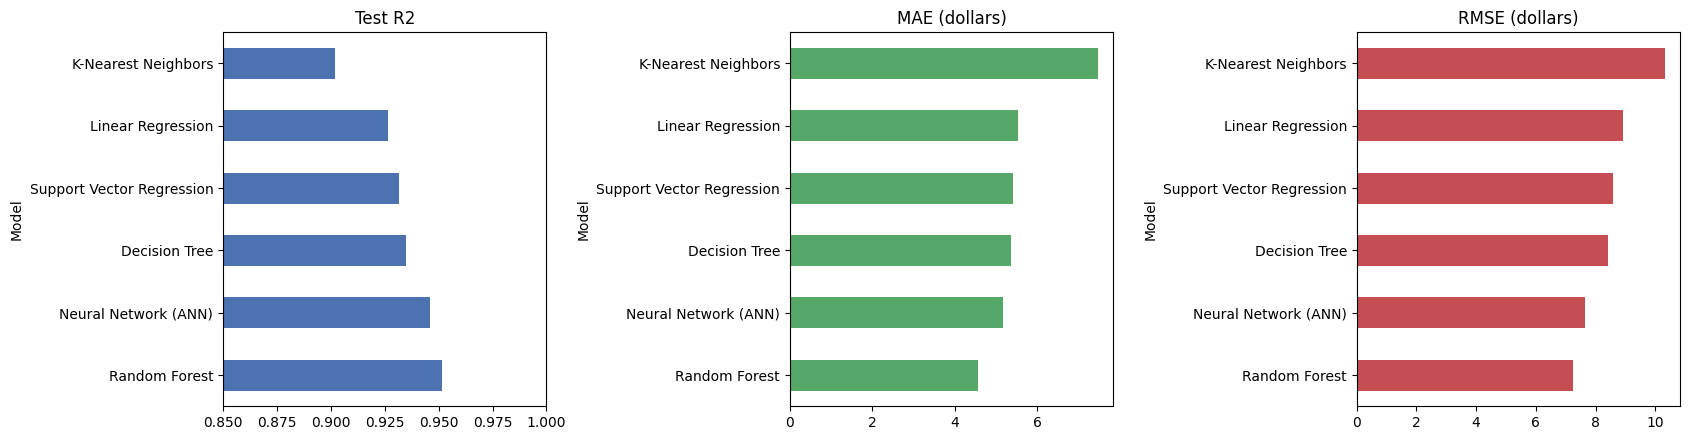

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
c = comparison.set_index('Model')

c['Test R2'].plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Test R2'); axes[0].set_xlim(0.85, 1.0)

c['MAE ($)'].plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('MAE (dollars)')

c['RMSE ($)'].plot(kind='barh', ax=axes[2], color='#C44E52')
axes[2].set_title('RMSE (dollars)')

plt.tight_layout(); plt.show()

##07 Error analysis by trip type

A single headline MAE hides the fact that error is not uniform across trip
types. Using g_test (the answer key, kept aside at the split), the test
errors are grouped by their true pricing category.

To show what the engineered features actually contributed, the same model is
trained twice: once on a baseline feature set (raw coordinates, raw time
parts, weather) and once on the full engineered set.

In [60]:
BASE_COLS = ['hav_miles','pickup_latitude','pickup_longitude',
             'dropoff_latitude','dropoff_longitude','passenger_count',
             'hour','dayofweek','month','is_holiday',
             'temperature_f','precipitation_in','wind_speed_mph','traffic_index']
BASE_COLS = [c for c in BASE_COLS if c in X_train_scaled.columns]

before_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                     random_state=42, n_jobs=-1)
before_model.fit(X_train_scaled[BASE_COLS], y_train)
pred_before = before_model.predict(X_test_scaled[BASE_COLS])

pred_after = predictions['Random Forest']

print(f'MAE before engineered features : ${mean_absolute_error(y_test, pred_before):.2f}')
print(f'MAE after  engineered features : ${mean_absolute_error(y_test, pred_after):.2f}')

MAE before engineered features : $4.75
MAE after  engineered features : $4.57


In [61]:
from sklearn.linear_model import LinearRegression

lin_before = LinearRegression().fit(X_train_scaled[BASE_COLS], y_train)
lin_pred_before = lin_before.predict(X_test_scaled[BASE_COLS])
lin_pred_after  = predictions['Linear Regression']

print('RANDOM FOREST')
print(f'  before: ${mean_absolute_error(y_test, pred_before):.2f}   '
      f'after: ${mean_absolute_error(y_test, pred_after):.2f}')
print('LINEAR REGRESSION')
print(f'  before: ${mean_absolute_error(y_test, lin_pred_before):.2f}   '
      f'after: ${mean_absolute_error(y_test, lin_pred_after):.2f}')

RANDOM FOREST
  before: $4.75   after: $4.57
LINEAR REGRESSION
  before: $8.65   after: $5.53


**Why the two model families respond so differently.**

A random forest can partially reconstruct geography on its own. Given raw
latitude and longitude it splits repeatedly - lat < 40.66, then lon > -73.80 -
and effectively carves out an approximate box around JFK without being told
the airport exists. The engineered features hand it a shortcut it could
already find, so they improve it only modestly.

A linear model cannot do this. It fits a single global plane through the
coordinates and has no way to express "fare is flat at $70 inside this region
and metered everywhere else". Explicit airport distances, borough one-hots and
the regime flag are the only way that structure reaches it - which is why its
error falls by roughly a third.

The engineered features are not redundant. They are redundant only for models
that can approximate them internally.

In [62]:
NAMES = {1:'1 Standard metered', 2:'2 JFK flat fare', 3:'3 Newark',
         4:'4 Out-of-city flat', 5:'5 Negotiated'}

err = pd.DataFrame({
    'true_rate_code': g_test.values,
    'actual'        : y_test.values,
    'before'        : pred_before,
    'after'         : pred_after,
})
err['ae_before'] = (err.actual - err.before).abs()
err['ae_after']  = (err.actual - err.after).abs()

breakdown = err.groupby('true_rate_code').agg(
    n          = ('actual', 'size'),
    mean_fare  = ('actual', 'mean'),
    MAE_before = ('ae_before', 'mean'),
    MAE_after  = ('ae_after', 'mean'),
).round(2)

breakdown['improvement_$']    = (breakdown.MAE_before - breakdown.MAE_after).round(2)
breakdown['improvement_%']    = ((1 - breakdown.MAE_after / breakdown.MAE_before) * 100).round(1)
breakdown['MAE_as_%_of_fare'] = (breakdown.MAE_after / breakdown.mean_fare * 100).round(1)
breakdown.index = breakdown.index.map(NAMES)

breakdown

,n,mean_fare,MAE_before,MAE_after,improvement_$,improvement_%,MAE_as_%_of_fare
true_rate_code,,,,,,,
1 Standard metered,944,34.28,3.56,3.50,0.06,1.7,10.2
2 JFK flat fare,132,71.38,6.05,5.33,0.72,11.9,7.5
3 Newark,91,83.09,6.89,6.85,0.04,0.6,8.2
4 Out-of-city flat,43,171.32,20.52,19.16,1.36,6.6,11.2
5 Negotiated,32,29.92,7.06,6.71,0.35,5.0,22.4


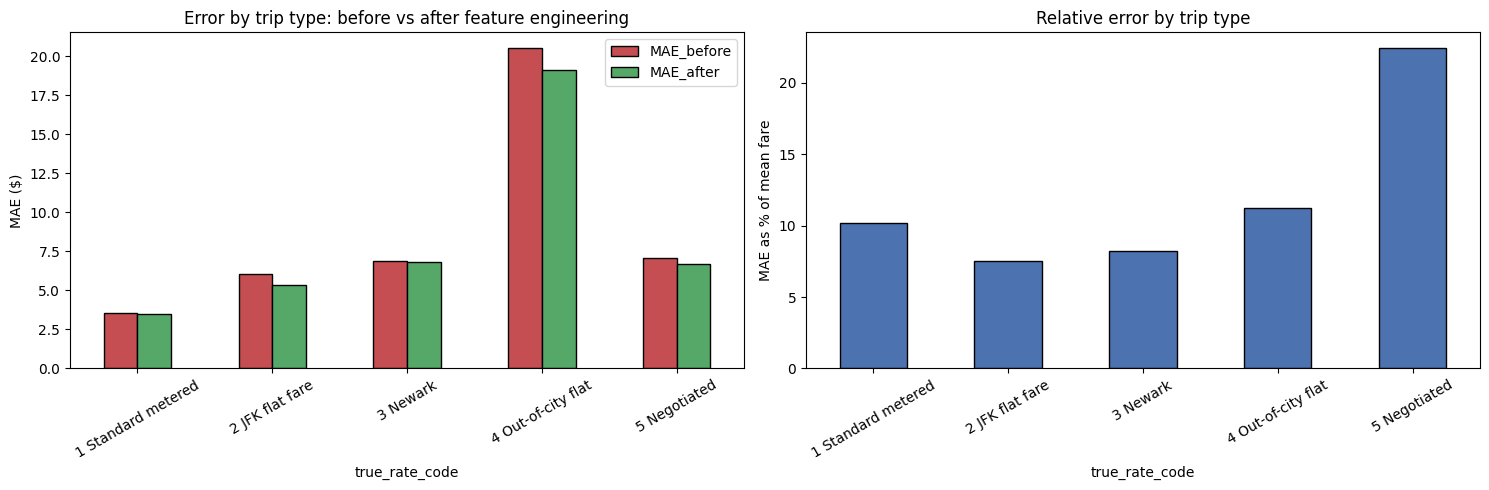

WORST CATEGORY: 4 Out-of-city flat
  MAE $19.16 vs mean fare $171.32
  5.5x the error of the best category


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

breakdown[['MAE_before','MAE_after']].plot(kind='bar', ax=axes[0],
        color=['#C44E52','#55A868'], edgecolor='black')
axes[0].set_ylabel('MAE ($)')
axes[0].set_title('Error by trip type: before vs after feature engineering')
axes[0].tick_params(axis='x', rotation=30)

breakdown['MAE_as_%_of_fare'].plot(kind='bar', ax=axes[1],
        color='#4C72B0', edgecolor='black')
axes[1].set_ylabel('MAE as % of mean fare')
axes[1].set_title('Relative error by trip type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

worst = breakdown.MAE_after.idxmax()
print(f'WORST CATEGORY: {worst}')
print(f'  MAE ${breakdown.loc[worst,"MAE_after"]:.2f} vs mean fare ${breakdown.loc[worst,"mean_fare"]:.2f}')
print(f'  {breakdown.MAE_after.max()/breakdown.MAE_after.min():.1f}x the error of the best category')

**What the breakdown shows.**

Error is not uniform across trip types. The out-of-city flat category carries
several times the absolute error of standard metered trips - it is the
smallest category, so the model has the least data to learn from, and its
fares are the largest, so the same relative error produces a much bigger
absolute one. Judged as a percentage of mean fare it sits much closer to the
others, which is why the second chart matters.

The negotiated category is the honest failure. Those fares are agreed between
driver and passenger and have no geographic or temporal signature, so no
feature available at quote time can predict them. The right production
response is a product decision rather than a better model: suppress the
quote, or show a range instead of a point estimate, for trips falling outside
the recognised regimes.

##08 Save the artifacts

In [64]:
import pickle

with open('taxi_fare_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

with open('encoder.pkl', 'wb') as file:
    pickle.dump(encoder_multi, file)

with open('imputer.pkl', 'wb') as file:
    pickle.dump(imputer, file)

print("Saved: model, scaler, encoder, imputer")

Saved: model, scaler, encoder, imputer
